# Segmentation masks

In [1]:
import pandas as pd
import numpy as np
import json
import os
from datetime import date

GEOJSON = "chunked_data/A_000217.geojson"
TRANSFORM = "images/A_000217_transform.json"
IMAGE_FILE = "images/A_000217.png"

def load_transform(transform_path):
    with open(transform_path, 'r') as f:
        return json.load(f)

def transform_polygon_to_pixels(polygon_coords, transform):
    """
    Converts a list of [x, y] world coordinates to pixel coordinates.
    """
    coords = np.array(polygon_coords)
    
    # 1. Shift by Min X
    pixel_x = (coords[:, 0] - transform['min_x']) * transform['pixel_per_unit']
    
    # 2. Shift by Max Y and FLIP (because image Y=0 is top, DXF Y=0 is bottom)
    pixel_y = (transform['max_y'] - coords[:, 1]) * transform['pixel_per_unit']
    
    # 3. Stack and Round
    return np.column_stack((pixel_x, pixel_y)).astype(int)

# ==========================================
# 2. DATAFRAME CREATION LOGIC
# ==========================================

def create_layout_dataframe(geojson_path, transform_path):
    """
    Parses GeoJSON and Transform file to create a Pandas DataFrame.
    """
    # Load external files
    try:
        with open(geojson_path, 'r') as f:
            geojson_data = json.load(f)
        transform = load_transform(transform_path)
    except FileNotFoundError as e:
        print(f"Error loading files: {e}")
        return pd.DataFrame()

    # Derive DXF filename from the geojson filename (assuming convention)
    # e.g., "chunked_data/Floor plan.geojson" -> "Floor plan.dxf"
    base_name = os.path.splitext(os.path.basename(geojson_path))[0]
    dxf_filename = f"{base_name}.dxf"

    rows = []

    print(f"[INFO] Processing {len(geojson_data['features'])} features...")

    for feature in geojson_data['features']:
        props = feature['properties']
        geom = feature['geometry']

        # Extract IDs
        layout_id = props.get('layout_id')
        chunk_id = props.get('chunk_id')

        # Extract and Transform Geometry
        # Note: GeoJSON polygons are usually [[[x,y], [x,y]...]] (list of rings)
        # We take the first ring (exterior)
        if geom and 'coordinates' in geom:
            raw_coords = geom['coordinates'][0]
            
            # Apply the transformation logic to get pixel coordinates
            pixel_poly = transform_polygon_to_pixels(raw_coords, transform)

            rows.append({
                'dxf_file': dxf_filename,
                'layout_id': layout_id,
                'chunk_id': chunk_id,
                'chunks': pixel_poly  # Storing the numpy array of pixels
            })

    # Create DataFrame
    df = pd.DataFrame(rows)
    return df
    
df = create_layout_dataframe(geojson_path=GEOJSON, transform_path=TRANSFORM)
df

[INFO] Processing 525 features...


,dxf_file,layout_id,chunk_id,chunks
0,A_000217.dxf,0,0,"[[1626, 601], [1626, 641], [1568, 641], [1568,..."
1,A_000217.dxf,0,0,"[[1088, 458], [1088, 426], [1529, 426], [1529,..."
2,A_000217.dxf,0,0,"[[1484, 458], [1484, 458], [1484, 458], [1484,..."
3,A_000217.dxf,0,0,"[[1088, 667], [1088, 484], [1456, 484], [1456,..."
4,A_000217.dxf,0,0,"[[1088, 688], [1088, 667], [1403, 667], [1403,..."
...,...,...,...,...
520,A_000217.dxf,9,0,"[[7651, 5246], [7651, 5246], [7651, 5246], [76..."
521,A_000217.dxf,9,0,"[[7743, 5272], [7745, 5273], [7746, 5275], [77..."
522,A_000217.dxf,9,0,"[[7740, 5300], [7740, 5300], [7740, 5300], [77..."
523,A_000217.dxf,9,0,"[[7730, 5281], [7735, 5281], [7735, 5284], [77..."


In [2]:
def generate_single_mask_json(
    df: pd.DataFrame,
    output_file: str = "all_chunk_masks.json",
    padding: int = 50,
    clip_to_image: bool = False,
    image_size: tuple = None  # (width, height) optional for clipping
):
    """
    Generates a single JSON with integer keys and robust polygon handling.
    """
    all_masks = {
        "layouts": {},
        "metadata": {
            "total_layouts": 0,
            "total_chunks": 0,
            "generated_on": str(date.today()),
            "padding_applied": padding,
            "source": "from DataFrame chunks column"
        }
    }

    unique_layouts = sorted(df['layout_id'].unique())
    all_masks["metadata"]["total_layouts"] = len(unique_layouts)

    total_chunks = 0

    for layout_id in unique_layouts:
        layout_df = df[df['layout_id'] == layout_id]
        unique_chunks = sorted(layout_df['chunk_id'].unique())

        # Use integer key!
        all_masks["layouts"][int(layout_id)] = {"chunks": {}}

        for chunk_id in unique_chunks:
            subset = layout_df[layout_df['chunk_id'] == chunk_id]

            polygons = []
            all_points = []

            for _, row in subset.iterrows():
                poly_raw = row['chunks']

                # Convert to list safely
                if isinstance(poly_raw, np.ndarray):
                    poly = poly_raw.tolist()
                elif isinstance(poly_raw, (list, tuple)):
                    poly = [list(p) if isinstance(p, (np.ndarray, tuple)) else p for p in poly_raw]
                else:
                    continue  # skip invalid

                # Ensure each point is [x, y] list of numbers
                clean_poly = []
                for pt in poly:
                    if isinstance(pt, (np.ndarray, list, tuple)):
                        pt_list = [float(coord) for coord in pt]
                        if len(pt_list) >= 2:
                            clean_poly.append(pt_list[:2])  # only x,y
                    elif isinstance(pt, (int, float)):
                        continue  # malformed
                if len(clean_poly) < 3:
                    continue  # skip degenerate polygons

                polygons.append(clean_poly)
                all_points.extend(clean_poly)

            if not polygons or not all_points:
                print(f"[WARN] Skipping empty/invalid chunk: layout {layout_id}, chunk {chunk_id}")
                continue

            points_np = np.array(all_points)
            min_x, min_y = points_np.min(axis=0)
            max_x, max_y = points_np.max(axis=0)

            left = min_x - padding
            top = min_y - padding
            right = max_x + padding
            bottom = max_y + padding

            # Optional: clip to image bounds
            if clip_to_image and image_size:
                w, h = image_size
                left = max(0, left)
                top = max(0, top)
                right = min(w, right)
                bottom = min(h, bottom)

            bbox = [float(left), float(top), float(right), float(bottom)]

            # Store with integer keys
            all_masks["layouts"][int(layout_id)]["chunks"][int(chunk_id)] = {
                "polygons": polygons,
                "bounding_box": bbox
            }
            total_chunks += 1

    all_masks["metadata"]["total_chunks"] = total_chunks
    print(f"Successfully generated {total_chunks} valid chunks across {len(unique_layouts)} layouts.")

    # Save
    os.makedirs(os.path.dirname(output_file) if os.path.dirname(output_file) else '.', exist_ok=True)
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(all_masks, f, indent=4, ensure_ascii=False)

    print(f"Saved to: {output_file}")
    return all_masks  # optionally return for immediate use

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
import numpy as np
import json
import os

def visualize_chunks(
    df=None,
    image_path=None,
    json_file=None,
    target_layouts=None,
    target_chunks=None,
    highlight_only=True,        # NEW: False = show all chunks; True = show only targets
    label_fontsize=9,
    alpha=0.5,
    figsize=(20, 12)
):
    """
    Visualize chunk masks on the FULL image (no cropping).
    
    Supports:
      - df + image_path
      - json_file + image_path
    
    Behavior:
      - Always shows the entire image
      - Highlights only the target_layouts / target_chunks
      - If target_layouts=None and target_chunks=None → shows ALL chunks
      - Labels appear only on visible (target) chunks
    """
    # === Input validation ===
    if df is not None and image_path is not None:
        mode = "dataframe"
    elif json_file is not None and image_path is not None:
        mode = "json"
    else:
        raise ValueError("Provide either (df + image_path) OR (json_file + image_path)")

    # Load full image
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    base_img = Image.open(image_path).convert("RGB")
    img_array = np.array(base_img)
    img_h, img_w = img_array.shape[:2]

    # === Collect polygons to draw ===
    polygons = []        # np.array polygons
    pair_info = []       # (layout_id, chunk_id, centroid)

    if mode == "dataframe":
        available_layouts = sorted(df['layout_id'].unique())
        if target_layouts is None:
            target_layouts = available_layouts
        elif not isinstance(target_layouts, (list, tuple)):
            target_layouts = [target_layouts]
        target_layouts = [int(l) for l in target_layouts]

        subset = df[df['layout_id'].isin(target_layouts)]
        if target_chunks is not None:
            if not isinstance(target_chunks, (list, tuple)):
                target_chunks = [target_chunks]
            subset = subset[subset['chunk_id'].isin(target_chunks)]

        if subset.empty:
            print(f"[WARN] No matching chunks found.")
            return

        for _, row in subset.iterrows():
            poly_raw = row['chunks']
            poly = poly_raw.tolist() if isinstance(poly_raw, np.ndarray) else poly_raw
            clean_poly = [[float(x), float(y)] for x, y in poly if isinstance(x, (int, float)) and isinstance(y, (int, float))]
            if len(clean_poly) < 3:
                continue
            poly_np = np.array(clean_poly)
            polygons.append(poly_np)
            centroid = poly_np.mean(axis=0)
            pair_info.append((row['layout_id'], row['chunk_id'], centroid))

    else:  # json mode
        if not os.path.exists(json_file):
            raise FileNotFoundError(f"JSON not found: {json_file}")
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        layouts_dict = data["layouts"]
        available_layouts = sorted([int(k) for k in layouts_dict.keys()])

        if target_layouts is None:
            target_layouts = available_layouts
        elif not isinstance(target_layouts, (list, tuple)):
            target_layouts = [target_layouts]
        target_layouts = [int(l) for l in target_layouts]

        for lid in target_layouts:
            key = str(lid) if str(lid) in layouts_dict else lid
            if key not in layouts_dict:
                continue
            chunks_dict = layouts_dict[key]["chunks"]
            for cid_str, chunk_data in chunks_dict.items():
                cid = int(cid_str)
                if target_chunks is not None and cid not in target_chunks:
                    continue
                for poly_list in chunk_data["polygons"]:
                    poly_np = np.array(poly_list, dtype=float)
                    if poly_np.shape[0] < 3:
                        continue
                    polygons.append(poly_np)
                    centroid = poly_np.mean(axis=0)
                    pair_info.append((lid, cid, centroid))

    if not polygons:
        print("[WARN] No valid polygons to display.")
        return

    unique_chunks = len(set((p[0], p[1]) for p in pair_info))
    print(f"Displaying {unique_chunks} selected chunks on full image")

    # === Plotting ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Raw full image
    ax1.imshow(img_array)
    ax1.set_title("Full Raw Image", fontsize=14)
    ax1.axis('off')

    # Overlay on full image
    ax2.imshow(img_array)

    # Color mapping for consistent colors per chunk
    unique_pairs = sorted(set((p[0], p[1]) for p in pair_info))
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    color_map = {pair: colors[i % 20] for i, pair in enumerate(unique_pairs)}

    labeled = set()

    for poly_np, (lid, cid, centroid) in zip(polygons, pair_info):
        color = color_map[(lid, cid)]

        ax2.add_patch(Polygon(poly_np, facecolor=color, alpha=alpha,
                              edgecolor='white', linewidth=1.2))

        # Label only once per chunk
        if (lid, cid) not in labeled:
            # ax2.text(centroid[0], centroid[1],
            #          f"L{lid} C{cid}",
            #          fontsize=label_fontsize,
            #          color='white',
            #          fontweight='bold',
            #          ha='center', va='center',
            #          bbox=dict(facecolor='black', alpha=0.8, boxstyle='round,pad=0.4'))
            labeled.add((lid, cid))

    ax2.set_title(f"Full Image with Selected Chunks Highlighted ({unique_chunks} chunks)", fontsize=14)
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

Displaying 238 selected chunks on full image


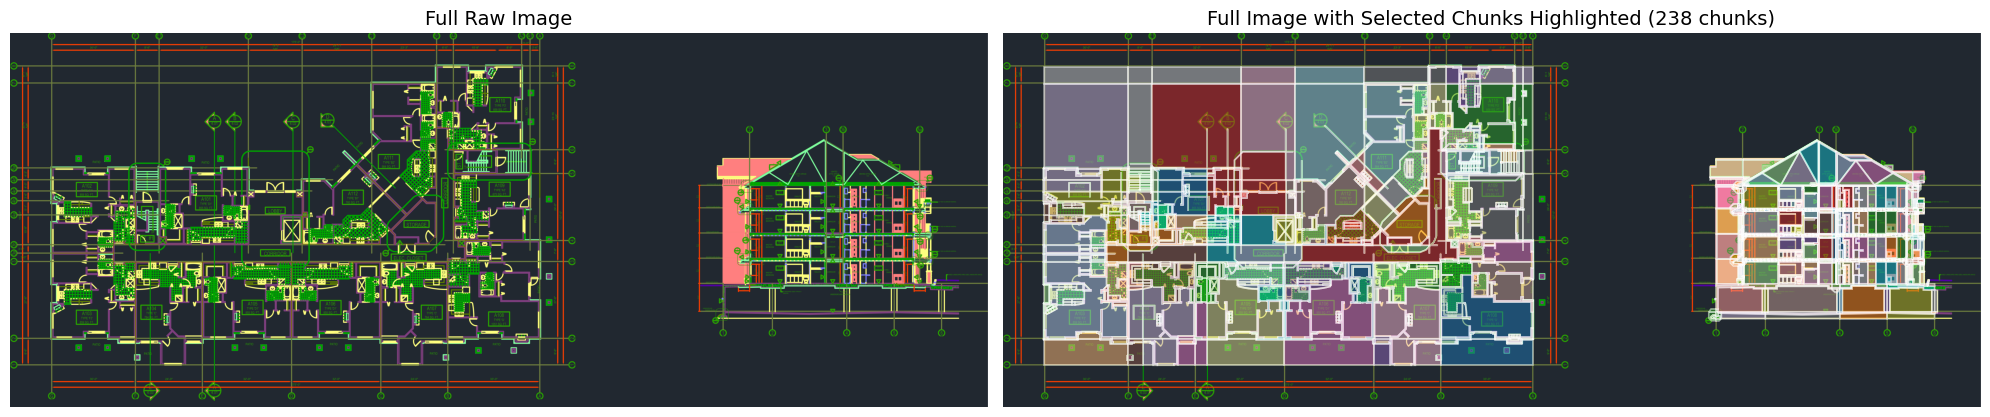

In [7]:
IMAGE_FILE = "images/AEC Plan Elev Sample.png"
JSON_FILE  = "chunk_masks/AEC Plan Elev Sample_masks.json"

# generate_single_mask_json(df, output_file=JSON_FILE, padding=50)

# 1. From DataFrame (during development)
# visualize_chunks(df=df, image_path=IMAGE_FILE)

# 2. From saved JSON (sharing, later viewing, no df needed)
visualize_chunks(json_file=JSON_FILE, image_path=IMAGE_FILE)

Displaying 61 selected chunks on full image


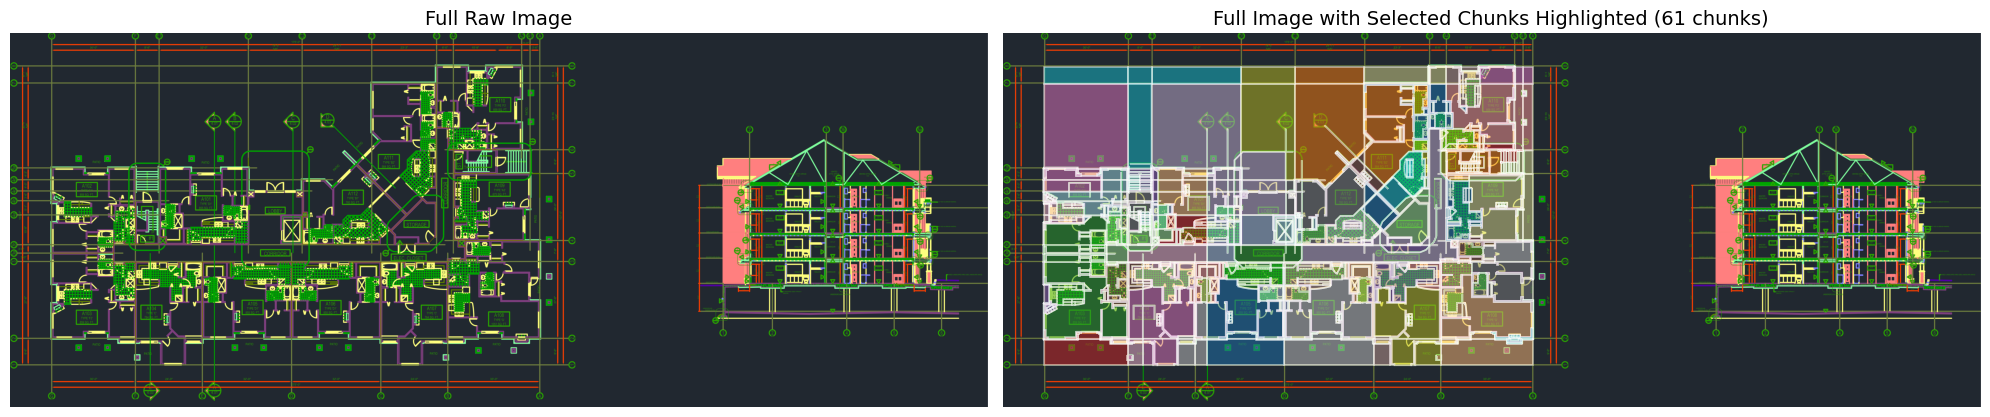

In [8]:
# 3. Specific layouts/chunks from JSON
visualize_chunks(json_file=JSON_FILE, image_path=IMAGE_FILE,
                 target_layouts=1)

# # 4. Only layout 1 from DataFrame
# visualize_chunks(df=df, image_path=IMAGE_FILE, target_layouts=1)